In [ ]:
# Install unrar in Colab
!apt-get install -y unrar

# Path to your RAR file
rar_path = "/content/numerals.rar"

# Extraction directory
extract_dir = "/content/numerals"

# Create directory if it doesn't exist
import os
os.makedirs(extract_dir, exist_ok=True)

# Extract RAR file
!unrar x "{rar_path}" "{extract_dir}/"

print("Files extracted to:", extract_dir)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data_path = '/content/numerals/numerals'

character_folders = sorted(os.listdir(data_path))

label_mapping = {folder: idx for idx, folder in enumerate(character_folders)}
print("Label mapping:", label_mapping)

image_data = []
image_labels = []

for label_name, label_idx in label_mapping.items():
    folder_path = os.path.join(data_path, label_name)
    image_files = sorted(os.listdir(folder_path))[:200]

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (32, 32))
        image_data.append(img.flatten())
        image_labels.append(label_idx)

image_data = np.array(image_data)
image_labels = np.array(image_labels)

df = pd.DataFrame(image_data)
df['label'] = image_labels

print("DataFrame shape:", df.shape)
print(df.head())

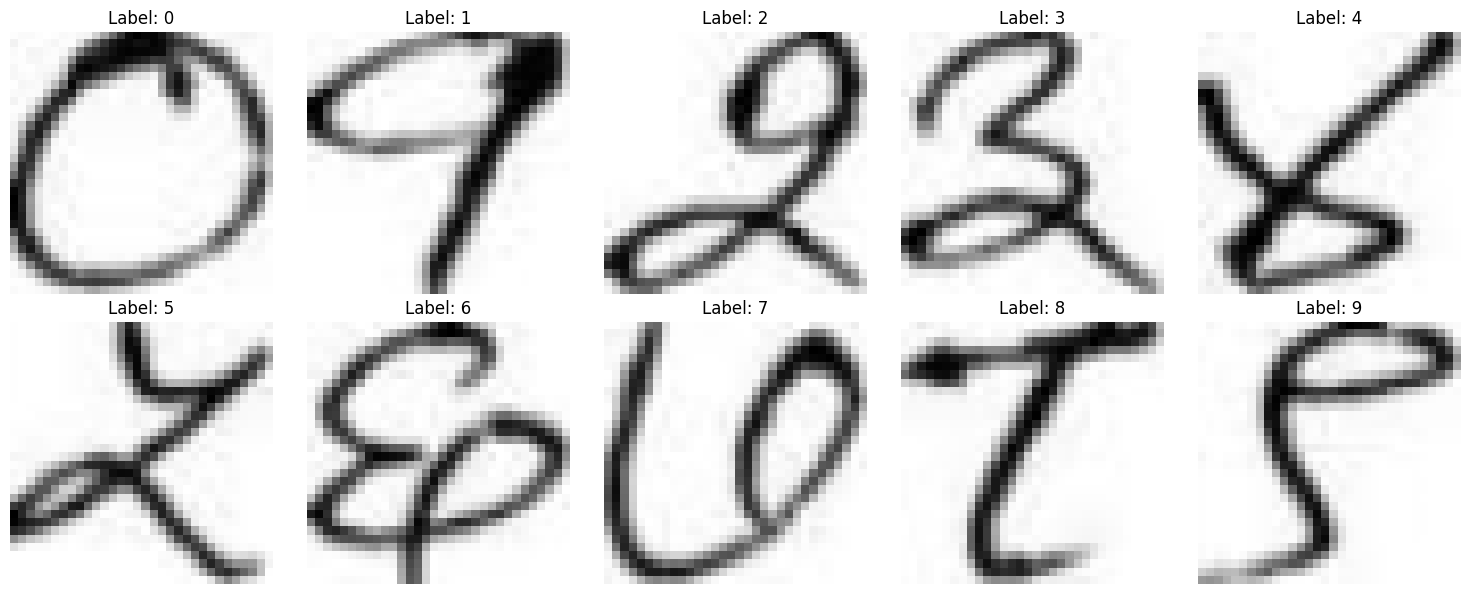

In [ ]:
rows = 2
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for idx, (label, group) in enumerate(df.groupby('label')):
    img_data = group.iloc[0, :-1]
    img = img_data.values.reshape(32, 32)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'Label: {label}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = np.array(image_data).astype('float32') / 255.0
y = np.array(image_labels)

X = X.reshape(-1, 32, 32, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

FILL IN THE BLANKS

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([

])



model.compile(

)


history = model.fit()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1869 - loss: 2.2650 - val_accuracy: 0.5625 - val_loss: 1.4901
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6430 - loss: 1.1576 - val_accuracy: 0.7031 - val_loss: 0.7673
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8038 - loss: 0.6387 - val_accuracy: 0.8188 - val_loss: 0.4578
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8645 - loss: 0.4289 - val_accuracy: 0.8562 - val_loss: 0.4075
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9059 - loss: 0.3060 - val_accuracy: 0.9062 - val_loss: 0.2719
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9418 - loss: 0.2024 - val_accuracy: 0.9375 - val_loss: 0.1985
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9466 - loss: 0.1600 - val_accuracy: 0.9531 - val_loss: 0.1517
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9598 - loss: 0.1196 - val_accuracy: 0.9563 - val_loss

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


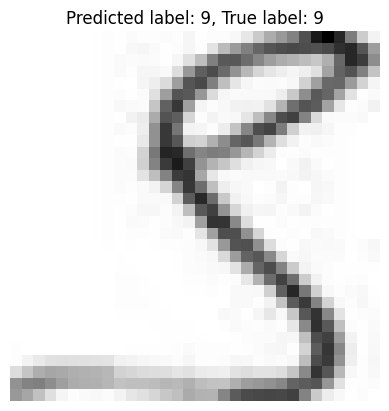

In [ ]:
predictions = model.predict(X_test)

import matplotlib.pyplot as plt

plt.imshow(X_test[0].reshape(32, 32), cmap='gray')
plt.title(f'Predicted label: {np.argmax(predictions[0])}, True label: {y_test[0]}')
plt.axis('off')
plt.show()

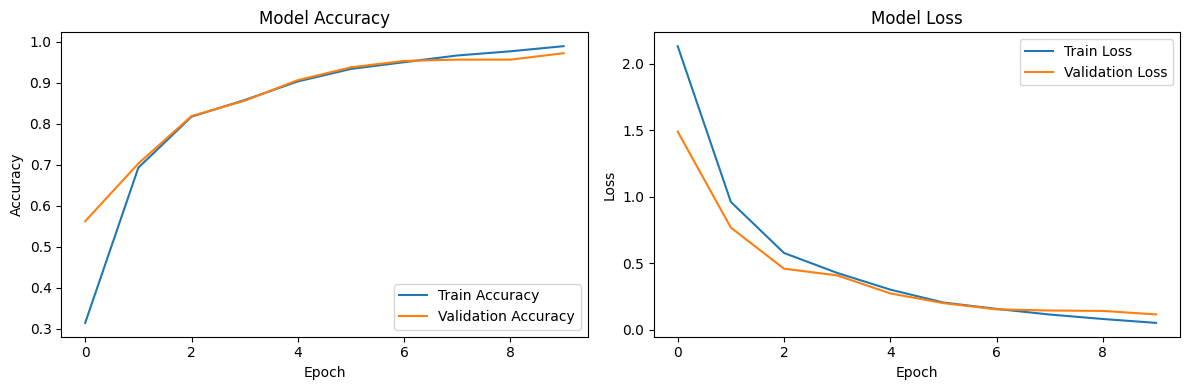

In [ ]:
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

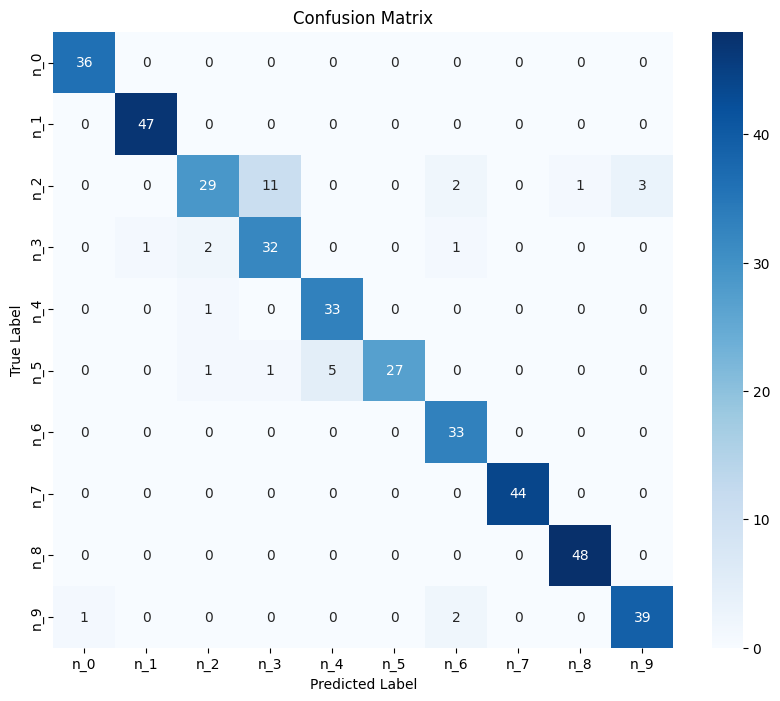

Classification Report:
              precision    recall  f1-score   support

         n_0       0.97      1.00      0.99        36
         n_1       0.98      1.00      0.99        47
         n_2       0.88      0.63      0.73        46
         n_3       0.73      0.89      0.80        36
         n_4       0.87      0.97      0.92        34
         n_5       1.00      0.79      0.89        34
         n_6       0.87      1.00      0.93        33
         n_7       1.00      1.00      1.00        44
         n_8       0.98      1.00      0.99        48
         n_9       0.93      0.93      0.93        42

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

report = classification_report(y_test, y_pred, target_names=label_mapping.keys())
print("Classification Report:")
print(report)